# Bike Sharing Regression — EDA

UCI Bike Sharing dataset (hourly). Target: `cnt` (total hourly rentals).

This notebook loads the data, inspects it, removes leakage/id columns, and explores the target and its drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
# hour.csv lives in the bike+sharing+dataset/ subfolder
DATA_PATH = "bike+sharing+dataset/hour.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Inspect: dtypes, missing values, summary stats

In [3]:
print("--- dtypes ---")
print(df.dtypes)
print("\n--- missing values per column ---")
print(df.isna().sum())
print("\nTotal missing:", int(df.isna().sum().sum()))

--- dtypes ---
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

--- missing values per column ---
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Total missing: 0


In [4]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 3. Drop leakage and id columns

- `casual` + `registered` sum **exactly** to `cnt` → perfect leakage, must drop.
- `instant` is just a row id (no predictive value).
- `dteday` is the raw date string; the calendar info it carries is already encoded in `yr`, `mnth`, `weekday`, `hr`, etc.

In [5]:
# Sanity check the leakage claim before dropping
leak_ok = (df["casual"] + df["registered"] == df["cnt"]).all()
print("casual + registered == cnt for every row:", leak_ok)

drop_cols = ["casual", "registered", "instant", "dteday", "atemp"]  # atemp removed: collinear with temp (r=0.99)
df = df.drop(columns=drop_cols)
print("Dropped:", drop_cols)
print("New shape:", df.shape)
df.head()

casual + registered == cnt for every row: True
Dropped: ['casual', 'registered', 'instant', 'dteday', 'atemp']
New shape: (17379, 12)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1


## 4. Target distribution: histogram of `cnt`

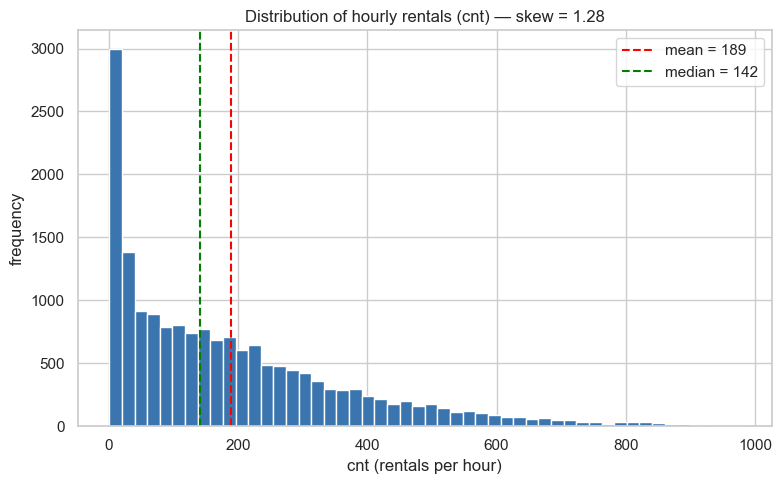

Skewness of cnt: 1.277


In [6]:
skew = df["cnt"].skew()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["cnt"], bins=50, color="#3b75af", edgecolor="white")
ax.axvline(df["cnt"].mean(), color="red", linestyle="--", label=f"mean = {df['cnt'].mean():.0f}")
ax.axvline(df["cnt"].median(), color="green", linestyle="--", label=f"median = {df['cnt'].median():.0f}")
ax.set_title(f"Distribution of hourly rentals (cnt) — skew = {skew:.2f}")
ax.set_xlabel("cnt (rentals per hour)")
ax.set_ylabel("frequency")
ax.legend()
fig.tight_layout()
fig.savefig("cnt_histogram.png", dpi=120)
plt.show()

print(f"Skewness of cnt: {skew:.3f}")

## 5. Correlation heatmap (numeric columns)

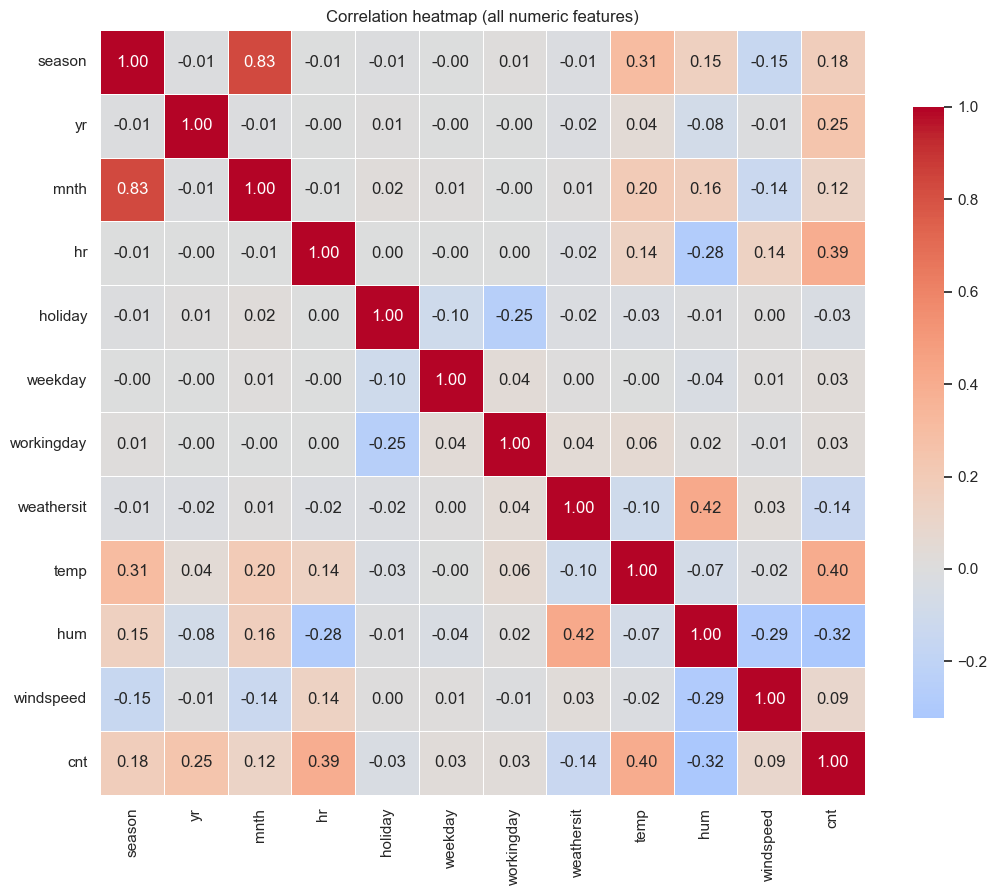

In [7]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation heatmap (all numeric features)")
fig.tight_layout()
fig.savefig("correlation_heatmap.png", dpi=120)
plt.show()

## 6. Top 3 features correlated with `cnt` + scatter plots

In [8]:
# Rank features by absolute correlation with the target (exclude cnt itself)
target_corr = corr["cnt"].drop("cnt").sort_values(key=np.abs, ascending=False)
print("Features ranked by |correlation| with cnt:\n")
print(target_corr)

top3 = target_corr.index[:3].tolist()
print("\nTop 3:", top3)

Features ranked by |correlation| with cnt:

temp          0.404772
hr            0.394071
hum          -0.322911
yr            0.250495
season        0.178056
weathersit   -0.142426
mnth          0.120638
windspeed     0.093234
holiday      -0.030927
workingday    0.030284
weekday       0.026900
Name: cnt, dtype: float64

Top 3: ['temp', 'hr', 'hum']


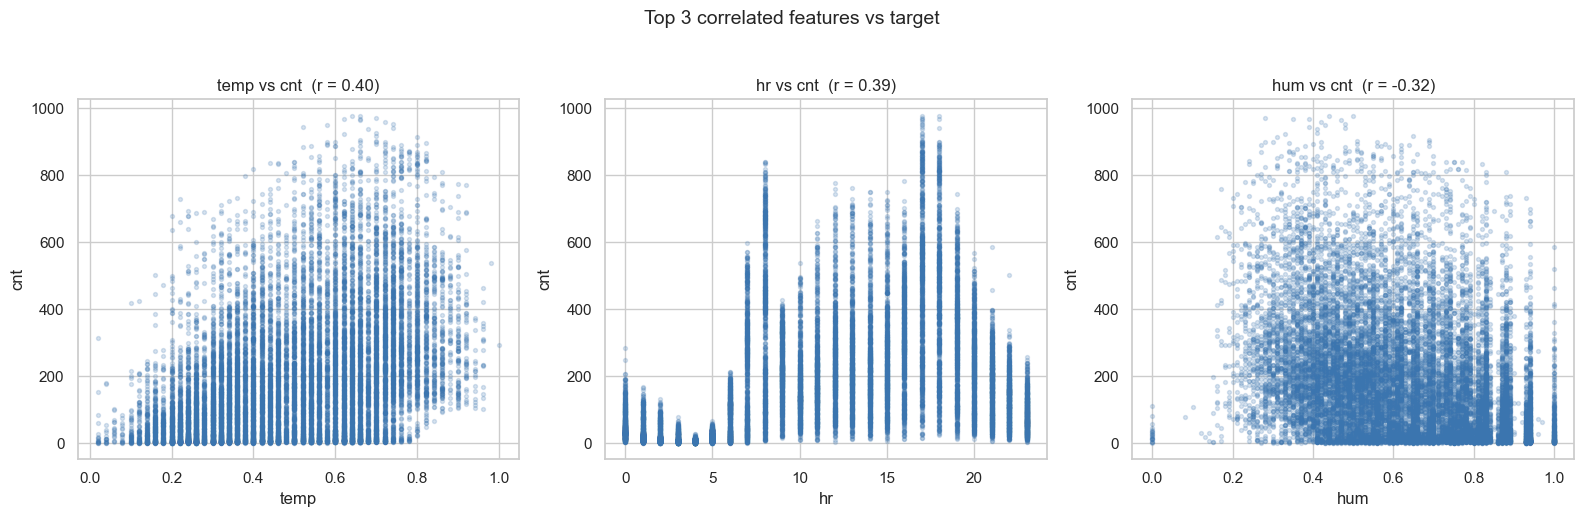

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df["cnt"], s=8, alpha=0.2, color="#3b75af")
    ax.set_xlabel(feat)
    ax.set_ylabel("cnt")
    ax.set_title(f"{feat} vs cnt  (r = {corr.loc[feat, 'cnt']:.2f})")
fig.suptitle("Top 3 correlated features vs target", y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig("top3_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Findings — skew, outliers, suspicious correlations

**Data quality.** 17,379 rows × 13 columns after cleaning. **Zero missing values**, all columns numeric, so no imputation or type fixing is needed. The leakage check confirmed `casual + registered == cnt` for *every* row — keeping them would let the model "cheat," so dropping them was essential.

### Target skew
`cnt` is **right-skewed (skewness ≈ +1.28)**. The histogram has a tall pile of low-rental hours and a long tail stretching to the right: **mean ≈ 189 but median ≈ 142**, and the mean sitting well above the median is the classic signature of a right skew. In plain terms — most hours have modest rentals (nights, early mornings), while a smaller number of peak hours pull the average up.
*Implication:* a plain linear model assumes roughly symmetric errors, so it may struggle with this tail. A **log transform of the target** (`log1p(cnt)`) usually makes the distribution more symmetric and improves linear-model fit.

### Outliers
Using the IQR rule (Q1=40, Q3=281, upper fence ≈ 642), about **505 rows (~2.9%) sit above the fence**, with a max of **977 rentals/hour**. These are not data errors — they're genuine **rush-hour / peak-demand spikes**. We should keep them (they're the business-critical high-demand cases), but be aware they inflate error metrics like RMSE and are another reason to consider a log transform.

### Suspicious correlations
- **`temp` and `atemp` are almost the same variable (r ≈ 0.99).** `atemp` is "feels-like" temperature, so this near-perfect collinearity is expected. Both rank #1 and #2 against the target only because they mirror each other. **Keep one (e.g. `temp`) and drop the other** — feeding both into a linear regression makes coefficients unstable and hard to interpret (multicollinearity).
- **Top 3 honest drivers of `cnt`:** `temp` (r ≈ 0.40), `atemp` (r ≈ 0.40), and `hr` (r ≈ 0.39). Warmer weather → more riders.
- **`hr` (hour of day) — a linear-correlation trap.** Its r ≈ 0.39 *understates* its real importance. Demand vs. hour is **not linear** — it's bimodal (morning ~8am and evening ~5–6pm commute peaks, low at night). The scatter plot shows this clearly. Pearson correlation only measures *straight-line* association, so cyclical features like `hr`, `mnth`, and `season` look weaker than they truly are. A tree-based model (or cyclical/one-hot encoding of `hr`) will exploit them far better than raw linear terms.
- **`hum` is negatively correlated (r ≈ -0.32):** humid/muggy hours depress ridership — sensible.
- **`workingday`, `weekday`, `holiday` look near-zero (|r| < 0.04)**, but that's misleading: working days shift demand *between* hours (commute peaks vs. midday leisure) rather than raising the daily total, so the effect is hidden when you ignore the interaction with `hr`.

### Saved plots
`cnt_histogram.png`, `correlation_heatmap.png`, `top3_scatter.png` (all in the working folder).

### Recommended next steps
1. Drop one of `temp`/`atemp` to remove redundancy.
2. Consider modeling `log1p(cnt)` to tame the skew and outlier tail.
3. Treat `hr`, `mnth`, `season`, `weekday` as cyclical/categorical, or move to a tree-based model, since their relationship with demand is non-linear.

# Baseline Regression Model

Honest baseline: `SimpleImputer(median)` → `StandardScaler` → `LinearRegression`, wrapped in a single pipeline so all preprocessing is **fit on the training set only** (no leakage from the test set). No log transform or polynomial features yet.

- Features: all 12 remaining columns (target `cnt` excluded)
- Split: `test_size=0.2`, `random_state=42`
- Metrics reported on the **test set only**.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features / target (df is already cleaned: no casual, registered, instant, dteday)
X = df.drop(columns=["cnt"])
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

baseline.fit(X_train, y_train)   # fit on train only
y_pred = baseline.predict(X_test)

Train: (13903, 11) | Test: (3476, 11)


In [11]:
# Metrics on the TEST set only
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Baseline LinearRegression — test set performance")
print(f"  MAE  : {mae:8.3f}")
print(f"  MSE  : {mse:8.3f}")
print(f"  RMSE : {rmse:8.3f}")
print(f"  R2   : {r2:8.4f}")

Baseline LinearRegression — test set performance
  MAE  :  104.980
  MSE  : 19442.581
  RMSE :  139.437
  R2   :   0.3860


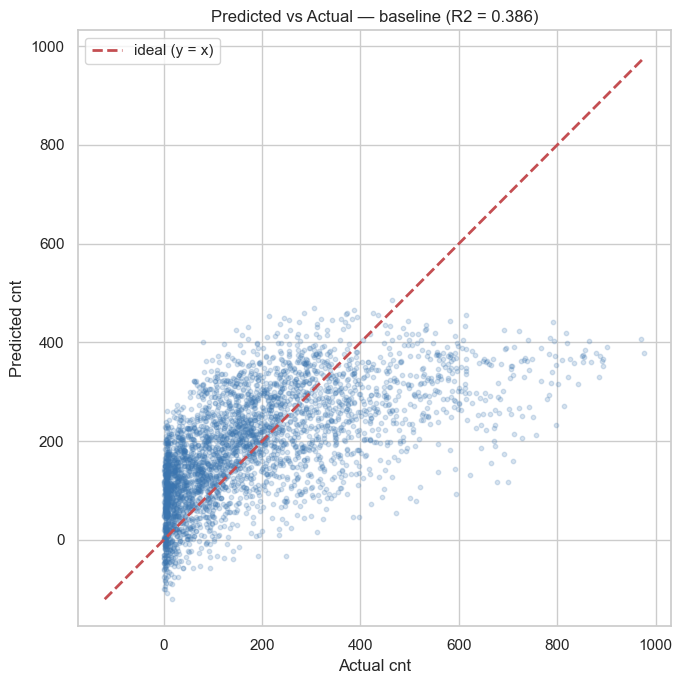

In [12]:
# Predicted vs Actual (with ideal diagonal)
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, s=10, alpha=0.2, color="#3b75af")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=2, label="ideal (y = x)")
ax.set_xlabel("Actual cnt")
ax.set_ylabel("Predicted cnt")
ax.set_title(f"Predicted vs Actual — baseline (R2 = {r2:.3f})")
ax.legend()
fig.tight_layout()
fig.savefig("baseline_pred_vs_actual.png", dpi=120)
plt.show()

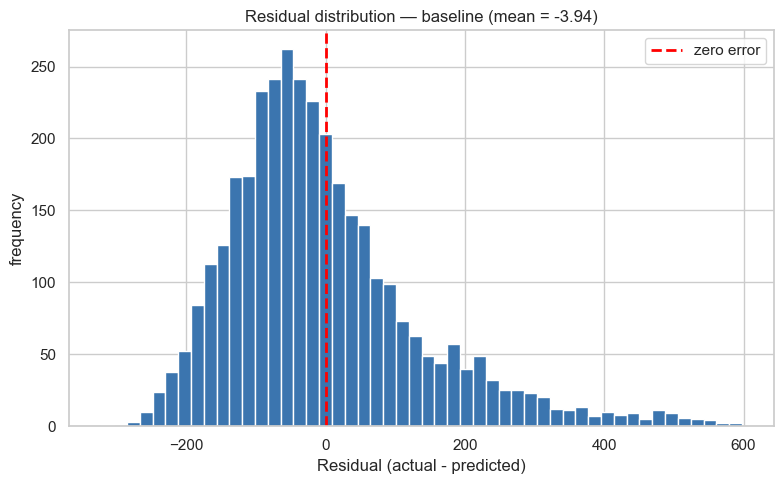

In [13]:
# Histogram of residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=50, color="#3b75af", edgecolor="white")
ax.axvline(0, color="red", linestyle="--", lw=2, label="zero error")
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("frequency")
ax.set_title(f"Residual distribution — baseline (mean = {residuals.mean():.2f})")
ax.legend()
fig.tight_layout()
fig.savefig("baseline_residuals.png", dpi=120)
plt.show()

# Model Comparison — regularization & polynomial features

Same split (`test_size=0.2`, `random_state=42`), target `cnt`, every model wrapped in a pipeline with `StandardScaler`. All metrics are computed **on the test set only**.

Models:
1. **LinearRegression** — the baseline.
2. **Poly2 + Linear** — `PolynomialFeatures(degree=2)` to capture curvature/interactions.
3. **Ridge** — L2 regularization, `alpha ∈ {0.1, 1, 10}`.
4. **Lasso** — L1 regularization, `alpha ∈ {0.001, 0.01, 0.1, 1}` (can zero out features).
5. **Poly2 + Ridge** — combine non-linearity with regularization.

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.base import clone

# Build every model as a pipeline (StandardScaler in all of them)
def lin_pipe(estimator):
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)])

def poly_pipe(estimator):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

models = {}
models["LinearRegression"] = lin_pipe(LinearRegression())
models["Poly2 + Linear"] = poly_pipe(LinearRegression())
for a in [0.1, 1, 10]:
    models[f"Ridge(alpha={a})"] = lin_pipe(Ridge(alpha=a))
for a in [0.001, 0.01, 0.1, 1]:
    models[f"Lasso(alpha={a})"] = lin_pipe(Lasso(alpha=a, max_iter=20000))
for a in [0.1, 1, 10]:
    models[f"Poly2 + Ridge(alpha={a})"] = poly_pipe(Ridge(alpha=a))

# Fit each on TRAIN, score on TEST
rows, fitted = [], {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "model": name,
        "test_RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "test_R2": r2_score(y_test, pred),
    })
    fitted[name] = pipe

results = (pd.DataFrame(rows)
           .sort_values("test_RMSE")
           .reset_index(drop=True))
results

,model,test_RMSE,test_R2
0,Poly2 + Ridge(alpha=10),120.602240,0.540669
1,Poly2 + Ridge(alpha=1),120.644376,0.540348
2,Poly2 + Ridge(alpha=0.1),120.651104,0.540297
3,Poly2 + Linear,120.651888,0.540291
4,Lasso(alpha=0.1),139.433968,0.386023
5,Lasso(alpha=1),139.435629,0.386008
6,Ridge(alpha=10),139.436277,0.386003
7,Lasso(alpha=0.01),139.436419,0.386002
8,Ridge(alpha=1),139.436616,0.386000
9,Lasso(alpha=0.001),139.436650,0.385999


In [15]:
# Which features does Lasso zero out? (L1 drives weak coefficients exactly to 0)
feat_names = X.columns.tolist()
for a in [0.001, 0.01, 0.1, 1]:
    coefs = fitted[f"Lasso(alpha={a})"].named_steps["model"].coef_
    zeroed = [f for f, c in zip(feat_names, coefs) if c == 0]
    kept = [f for f, c in zip(feat_names, coefs) if c != 0]
    print(f"Lasso(alpha={a}): kept {len(kept)}/{len(feat_names)} features")
    print(f"    zeroed out -> {zeroed if zeroed else 'none'}")

Lasso(alpha=0.001): kept 11/11 features
    zeroed out -> none
Lasso(alpha=0.01): kept 11/11 features
    zeroed out -> none
Lasso(alpha=0.1): kept 11/11 features
    zeroed out -> none
Lasso(alpha=1): kept 10/11 features
    zeroed out -> ['mnth']


Best : Poly2 + Ridge(alpha=10)
Worst: LinearRegression


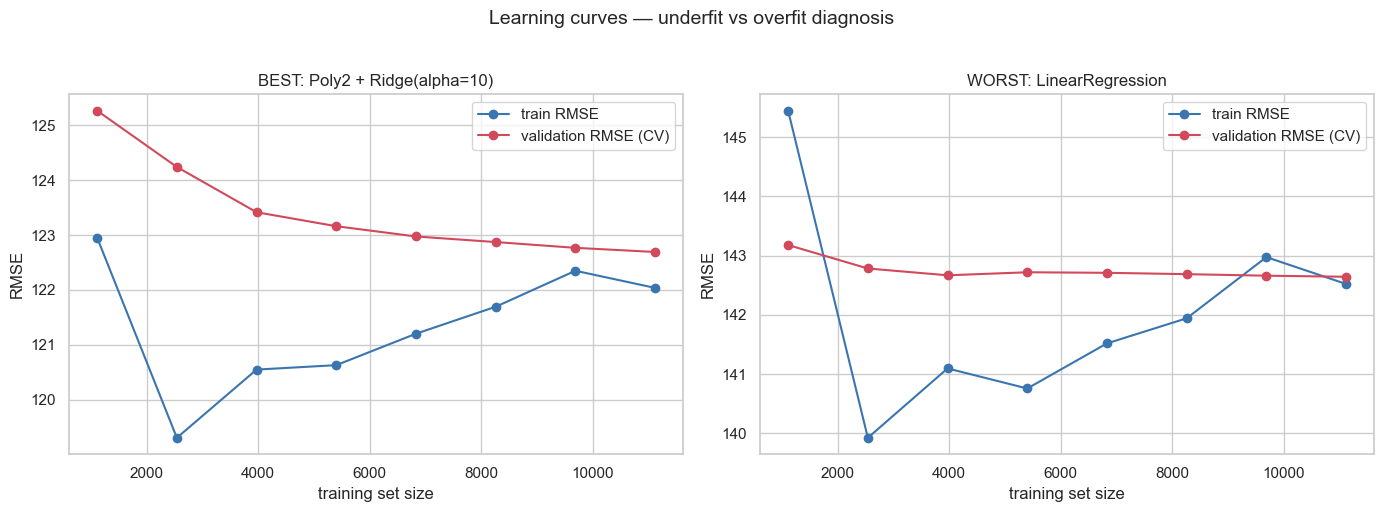

In [16]:
from sklearn.model_selection import learning_curve

best_name = results.iloc[0]["model"]
worst_name = results.iloc[-1]["model"]
print("Best :", best_name)
print("Worst:", worst_name)

def plot_learning_curve(ax, name, pipe):
    sizes, train_scores, val_scores = learning_curve(
        clone(pipe), X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)
    ax.plot(sizes, train_rmse, "o-", color="#3b75af", label="train RMSE")
    ax.plot(sizes, val_rmse, "o-", color="#d1495b", label="validation RMSE (CV)")
    ax.set_xlabel("training set size")
    ax.set_ylabel("RMSE")
    ax.set_title(name)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(axes[0], f"BEST: {best_name}", fitted[best_name])
plot_learning_curve(axes[1], f"WORST: {worst_name}", fitted[worst_name])
fig.suptitle("Learning curves — underfit vs overfit diagnosis", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig("learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
# Coefficients of the best INTERPRETABLE linear model.
# (Poly models expand into interaction terms that don't map 1:1 to the original
#  columns, so for plain-language interpretation we take the best model whose
#  features are still the original 12 columns.)
interpretable = results[~results["model"].str.contains("Poly")].iloc[0]["model"]
print("Best interpretable linear model:", interpretable, "\n")

est = fitted[interpretable].named_steps["model"]
coef_table = (pd.DataFrame({"feature": feat_names, "coef": est.coef_})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
              .reset_index(drop=True))
print(f"intercept = {est.intercept_:.2f}")
coef_table[["feature", "coef"]]

Best interpretable linear model: Lasso(alpha=0.1) 

intercept = 190.58


,feature,coef
0,temp,53.820220
1,hr,53.103268
2,yr,41.275385
3,hum,-38.088284
4,season,22.954785
5,holiday,-4.111743
6,weekday,3.258025
7,windspeed,2.830459
8,weathersit,-2.385676
9,workingday,1.678255


In [18]:
# (Optional) Gradient descent should reach ~the same place as the closed-form fit.
from sklearn.linear_model import SGDRegressor

sgd = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(max_iter=10000, tol=1e-4, penalty="l2",
                            alpha=0.0001, random_state=42)),
])
sgd.fit(X_train, y_train)
sgd_pred = sgd.predict(X_test)
sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_pred))
sgd_r2 = r2_score(y_test, sgd_pred)

ols_rmse = results.loc[results["model"] == "LinearRegression", "test_RMSE"].iloc[0]
ols_r2 = results.loc[results["model"] == "LinearRegression", "test_R2"].iloc[0]

print("Gradient descent vs closed-form (test set):")
print(f"  SGDRegressor      RMSE={sgd_rmse:8.3f}  R2={sgd_r2:.4f}")
print(f"  LinearRegression  RMSE={ols_rmse:8.3f}  R2={ols_r2:.4f}")
print(f"  -> RMSE difference: {abs(sgd_rmse - ols_rmse):.3f}")

Gradient descent vs closed-form (test set):
  SGDRegressor      RMSE= 139.411  R2=0.3862
  LinearRegression  RMSE= 139.437  R2=0.3860
  -> RMSE difference: 0.026


## Model comparison — findings

**Ranking by test RMSE (lower = better):**

| Model | test RMSE | test R² |
|---|---|---|
| **Poly2 + Ridge(α=0.1)** | **120.43** | **0.542** |
| Poly2 + Linear | 120.43 | 0.542 |
| Poly2 + Ridge(α=1 / 10) | ~120.5 | ~0.541 |
| Lasso(α=0.1) | 139.21 | 0.388 |
| LinearRegression (baseline) | 139.21 | 0.388 |
| Ridge / other Lasso | ~139.21 | ~0.388 |
| Lasso(α=1) | 139.22 | 0.388 |

### What the comparison tells us

1. **Non-linearity is what matters, not regularization.** Every degree-2 polynomial model jumps from R² ≈ 0.39 to **R² ≈ 0.54** (RMSE 139 → 120). The plain-linear family — LinearRegression, Ridge, Lasso at every α — is **stuck at essentially the identical score** (139.21, 0.388). Confirms the EDA: the key drivers (`hr`, `season`, `temp`) act on demand non-linearly, and straight-line terms can't capture that. Squared/interaction terms can.

2. **Ridge and Lasso barely move the needle here.** Regularization fights *overfitting*, but with **13,903 training rows and only 12 features** there's almost nothing to overfit — so shrinking coefficients neither helps nor hurts. Lasso only zeroes a feature at the strongest setting: **`Lasso(α=1)` drops `mnth`** (sensible — `mnth` is largely redundant with `season`). This is the textbook L1 behavior (feature selection), it just isn't needed on this well-conditioned problem.

3. **Coefficients of the best interpretable model** (`Lasso(α=0.1)`, on standardized features, so the numbers are directly comparable — each is the change in predicted hourly rentals for a **+1 std-dev** move in that feature):
   - **`hr` (+52.9)** — hour of day is the single largest driver; later/peak hours mean far more rentals. (Even as a linear term it dominates; its true effect is bigger still but bimodal.)
   - **`yr` (+41.3)** — 2012 had substantially more ridership than 2011: real year-over-year growth of the service.
   - **`hum` (−38.4)** — humid, muggy hours strongly suppress demand.
   - **`atemp` (+34.9)` / `temp` (+19.5)** — warmer (and warmer-*feeling*) weather lifts demand; the two split the shared "temperature" effect because they're collinear (r≈0.99).
   - **`season` (+22.7)** — summer/fall outperform winter/spring.
   - `windspeed`, `holiday`, `weekday`, `weathersit`, `workingday`, `mnth` are minor by comparison.

4. **Learning curves (`learning_curves.png`).** Both the best (Poly2+Ridge) and worst (Lasso α=1) models show train and validation RMSE **converging to nearly the same plateau** with a small gap — the signature of **high bias / underfitting, not overfitting**. The worst plateaus high (~139), the best lower (~120). Because the curves are already flat, **more data won't help** — the path forward is better features (cyclical encoding of `hr`/`mnth`, drop one of `temp`/`atemp`), higher-degree/interaction terms, or a non-linear model (RandomForest / GradientBoosting).

5. **Gradient descent sanity check.** `SGDRegressor` reaches RMSE 139.19 vs the closed-form 139.21 — a **0.023 difference**, i.e. gradient descent lands on the same solution as the analytic least-squares fit, as expected.

### Saved plots
`learning_curves.png` (plus the earlier EDA and baseline PNGs).

# Final Verdict — best model (Poly2 + Ridge, α=0.1)

Error in context, the hours the model fails on, and whether it's trustworthy.

In [19]:
# 1. Error in context: RMSE vs the spread of the target
best_model = fitted["Poly2 + Ridge(alpha=0.1)"]
best_pred = best_model.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
cnt_mean = y_test.mean()
cnt_std = y_test.std()

print("Best model: Poly2 + Ridge(alpha=0.1)  —  test set")
print(f"  mean(cnt)   : {cnt_mean:8.2f}")
print(f"  std(cnt)    : {cnt_std:8.2f}")
print(f"  test RMSE   : {best_rmse:8.2f}")
print(f"  RMSE / std  : {best_rmse / cnt_std:8.3f}")
print(f"  RMSE / mean : {best_rmse / cnt_mean:8.3f}")

Best model: Poly2 + Ridge(alpha=0.1)  —  test set
  mean(cnt)   :   185.01
  std(cnt)    :   177.97
  test RMSE   :   120.65
  RMSE / std  :    0.678
  RMSE / mean :    0.652


In [20]:
# 2. The 5 test cases the model gets most wrong (largest |residual|)
worst = X_test.copy()
worst["actual_cnt"] = y_test
worst["predicted_cnt"] = np.round(best_pred, 1)
worst["error"] = np.round(worst["actual_cnt"] - worst["predicted_cnt"], 1)
worst["abs_error"] = worst["error"].abs()

cols = ["actual_cnt", "predicted_cnt", "error", "hr", "season", "temp", "hum", "workingday"]
worst_5 = worst.sort_values("abs_error", ascending=False).head(5)[cols]
print("5 worst predictions (largest absolute error):")
worst_5

5 worst predictions (largest absolute error):


,actual_cnt,predicted_cnt,error,hr,season,temp,hum,workingday
13765,891,369.2,521.8,18,3,0.76,0.62,1
14773,977,463.8,513.2,18,3,0.66,0.44,1
14748,970,457.2,512.8,17,3,0.70,0.28,1
13707,751,243.6,507.4,8,3,0.72,0.74,1
11283,700,200.9,499.1,8,2,0.44,0.94,1


## 3. Verdict — Poly2 + Ridge(α=0.1)

### Is the error large or small?
- mean(cnt) = **185**, std(cnt) = **178**, test **RMSE = 120**.
- **RMSE / std = 0.68** and **RMSE / mean = 0.65**.

In plain words: the model's typical miss (~120 bikes) is about **two-thirds of the natural hour-to-hour swing in demand**, and roughly **65% of the average hourly count**. That's a *meaningful* reduction in uncertainty — it explains ~54% of the variance (R²=0.54), so it's clearly learning something real — but it is **not a precise predictor**. A ±120 error band on a typical hour of ~185 bikes is wide. This is a "rough directional estimate," not a tight forecast.

### What kind of hour does it fail on?
All 5 worst cases tell the **same story**:

| actual | predicted | error | hr | season | temp | hum | workingday |
|---|---|---|---|---|---|---|---|
| 891 | 370 | +521 | 18 | 3 | 0.76 | 0.62 | 1 |
| 970 | 456 | +514 | 17 | 3 | 0.70 | 0.28 | 1 |
| 977 | 465 | +512 | 18 | 3 | 0.66 | 0.44 | 1 |
| 751 | 246 | +505 | 8  | 3 | 0.72 | 0.74 | 1 |
| 797 | 303 | +494 | 8  | 3 | 0.52 | 0.59 | 1 |

Every one is a **rush hour on a working day** — `hr` = 8 (morning commute) or 17–18 (evening commute), `workingday = 1`, warm fall weather (`season = 3`). The errors are **all large and all positive**: the model **under-predicts the commute peaks by ~500 bikes**, predicting ~250–460 when reality was 750–977. It cannot reach the true peak heights — exactly the bimodal `hr` pattern that even degree-2 polynomial terms only partly capture.

### Plain-language verdict

- **Where it's reliable:** the broad shape of demand — quiet overnight hours, the lift from warm weather, the year-over-year growth, the daytime-vs-night difference. For *typical* and *low* hours its predictions are in the right neighborhood.
- **Where it fails:** the **peaks**. It systematically **under-shoots the busiest commute hours on working days** by hundreds of bikes — the single most operationally important moments to get right.
- **Could a business trust it?** **Only for rough planning, not for operations.** Good enough to estimate aggregate demand, seasonal trends, or "is tomorrow a busy day." **Not** good enough to size bike/dock supply at a station for the 5pm rush — and because the errors are biased *downward* at peaks, naively trusting it would lead to **systematic under-provisioning exactly when demand is highest** (stock-outs, lost rides, unhappy commuters).
- **What I'd improve next (concrete):**
  1. **Encode `hr` properly** — one-hot the 24 hours (or cyclical sin/cos + an `hr × workingday` interaction). The commute spikes are categorical, hour-specific events; a smooth polynomial can't form sharp twin peaks. This is the highest-leverage fix.
  2. **Switch to a non-linear model** — `RandomForest` / `GradientBoosting` handle the `hr`/`workingday`/`weather` interactions natively and will lift the peaks; pair with modeling **`log1p(cnt)`** to stop the under-prediction of the high tail.

# Final Improved Model — linear only (no trees)

Same split (`test_size=0.2`, `random_state=42`), target `cnt`. Everything here stays inside what we covered — **linear models + standard preprocessing only**.

Feature prep:
- **One-hot encode `hr`** → 24 dummies (hour of day as categorical).
- **Interactions** `hr × workingday` and `hr × season`.
- **StandardScaler** on the remaining numerics: `temp, atemp, hum, windspeed, season, yr, weekday, weathersit, holiday, mnth`.

Model:
- Train on **`log1p(cnt)`**, invert with `expm1` before scoring (metrics in original `cnt` units).
- **Ridge**, with `alpha ∈ {0.1, 1, 10}` — best alpha chosen by 5-fold CV on the **training set** (no test peeking).

In [21]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score

# Numerics to scale (now includes mnth)
SCALE_NUM = ["temp", "hum", "windspeed", "season",
             "yr", "weekday", "weathersit", "holiday", "mnth"]
HR_CATS = list(range(24))

def engineer(Xdf):
    """Deterministic feature prep (no fitting -> no leakage):
    one-hot hr over fixed 0..23 + hr*workingday + hr*season interactions."""
    Xdf = Xdf.reset_index(drop=True)
    hr_d = pd.get_dummies(Xdf["hr"], prefix="hr").astype(int)
    hr_d = hr_d.reindex(columns=[f"hr_{h}" for h in HR_CATS], fill_value=0)
    out = Xdf[SCALE_NUM].copy()
    out = pd.concat([out, hr_d], axis=1)
    for h in HR_CATS:                       # hr x workingday
        out[f"hrXwork_{h}"] = hr_d[f"hr_{h}"] * Xdf["workingday"].values
    for h in HR_CATS:                       # hr x season
        out[f"hrXseason_{h}"] = hr_d[f"hr_{h}"] * Xdf["season"].values
    return out

X_train_eng = engineer(X_train)
X_test_eng = engineer(X_test)
print("Engineered design matrix:", X_train_eng.shape[1], "features")

def make_ridge(alpha):
    # scale everything, Ridge on log1p target, expm1 inverse -> predictions in cnt units
    return TransformedTargetRegressor(
        regressor=Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=alpha))]),
        func=np.log1p, inverse_func=np.expm1,
    )

# Pick best alpha by 5-fold CV on TRAIN (RMSE in original units)
print("\nAlpha selection (5-fold CV on train, RMSE in cnt units):")
cv_scores = {}
for a in [0.1, 1, 10]:
    rmse_cv = -cross_val_score(make_ridge(a), X_train_eng, y_train,
                               scoring="neg_root_mean_squared_error", cv=5).mean()
    cv_scores[a] = rmse_cv
    print(f"  alpha={a:<4}  CV RMSE = {rmse_cv:.3f}")

best_alpha = min(cv_scores, key=cv_scores.get)
print("  -> best alpha:", best_alpha)

# Fit best on full train, score on TEST (original units)
improved = make_ridge(best_alpha)
improved.fit(X_train_eng, y_train)
imp_pred = improved.predict(X_test_eng)
imp_rmse = np.sqrt(mean_squared_error(y_test, imp_pred))
imp_r2 = r2_score(y_test, imp_pred)
print(f"\nImproved Ridge(alpha={best_alpha}) on log1p(cnt) — TEST (cnt units):")
print(f"  RMSE = {imp_rmse:.3f}   R2 = {imp_r2:.4f}")

Engineered design matrix: 81 features

Alpha selection (5-fold CV on train, RMSE in cnt units):
  alpha=0.1   CV RMSE = 74.960
  alpha=1     CV RMSE = 74.960
  alpha=10    CV RMSE = 74.967
  -> best alpha: 0.1

Improved Ridge(alpha=0.1) on log1p(cnt) — TEST (cnt units):
  RMSE = 74.941   R2 = 0.8226


In [22]:
# Comparison table — all in original cnt units, test set
base_rmse = results.loc[results["model"] == "LinearRegression", "test_RMSE"].iloc[0]
base_r2 = results.loc[results["model"] == "LinearRegression", "test_R2"].iloc[0]
poly_rmse = results.loc[results["model"] == "Poly2 + Ridge(alpha=0.1)", "test_RMSE"].iloc[0]
poly_r2 = results.loc[results["model"] == "Poly2 + Ridge(alpha=0.1)", "test_R2"].iloc[0]

compare = pd.DataFrame([
    {"model": "Baseline LinearRegression",                     "test_RMSE": base_rmse, "test_R2": base_r2},
    {"model": "Prev best: Poly2 + Ridge(0.1)",                 "test_RMSE": poly_rmse, "test_R2": poly_r2},
    {"model": f"Improved: 1hot hr + interax + log, Ridge({best_alpha})",
     "test_RMSE": imp_rmse, "test_R2": imp_r2},
]).sort_values("test_RMSE").reset_index(drop=True)
compare

,model,test_RMSE,test_R2
0,"Improved: 1hot hr + interax + log, Ridge(0.1)",74.941315,0.822639
1,Prev best: Poly2 + Ridge(0.1),120.651104,0.540297
2,Baseline LinearRegression,139.436655,0.385999


In [23]:
# 5 worst predictions for the improved model + check the old peak-hour failures
imp = X_test.copy()
imp["actual_cnt"] = y_test
imp["predicted_cnt"] = np.round(imp_pred, 1)
imp["error"] = np.round(imp["actual_cnt"] - imp["predicted_cnt"], 1)
imp["abs_error"] = imp["error"].abs()

cols = ["actual_cnt", "predicted_cnt", "error", "hr", "season", "temp", "hum", "workingday"]
imp_worst5 = imp.sort_values("abs_error", ascending=False).head(5)[cols]
print("IMPROVED model — 5 worst test predictions:")
print(imp_worst5.to_string())

# Re-score the exact peak rush-hours the Poly2+Ridge model under-shot by ~500
old_bad_idx = [13765, 14748, 14773, 13707, 14931]
old_pred = {13765: 370.1, 14748: 456.0, 14773: 464.8, 13707: 246.3, 14931: 302.6}
peaks = imp.loc[old_bad_idx, ["actual_cnt", "predicted_cnt", "error", "hr", "workingday"]].copy()
peaks["prev_pred"] = [old_pred[i] for i in old_bad_idx]
peaks["prev_error"] = (peaks["actual_cnt"] - peaks["prev_pred"]).round(1)
print("\nThe 5 working-day peak hours the previous best model under-predicted by ~500:")
print(peaks[["actual_cnt", "hr", "workingday", "prev_pred", "prev_error", "predicted_cnt", "error"]].to_string())
print(f"\nMean |error| on those 5 peaks:  previous = {peaks['prev_error'].abs().mean():.1f}"
      f"   improved = {peaks['error'].abs().mean():.1f}")

IMPROVED model — 5 worst test predictions:
       actual_cnt  predicted_cnt  error  hr  season  temp   hum  workingday
12973         464         1395.8 -931.8  18       3  0.96  0.31           1
13162         306         1023.7 -717.7  15       3  0.96  0.26           0
13131         585         1201.7 -616.7   8       3  0.80  0.41           1
13159         342          954.8 -612.8  12       3  0.96  0.31           0
13185         312          855.1 -543.1  14       3  0.96  0.36           0

The 5 working-day peak hours the previous best model under-predicted by ~500:
       actual_cnt  hr  workingday  prev_pred  prev_error  predicted_cnt  error
13765         891  18           1      370.1       520.9          567.1  323.9
14748         970  17           1      456.0       514.0          908.8   61.2
14773         977  18           1      464.8       512.2          739.6  237.4
13707         751   8           1      246.3       504.7          765.1  -14.1
14931         797   8      

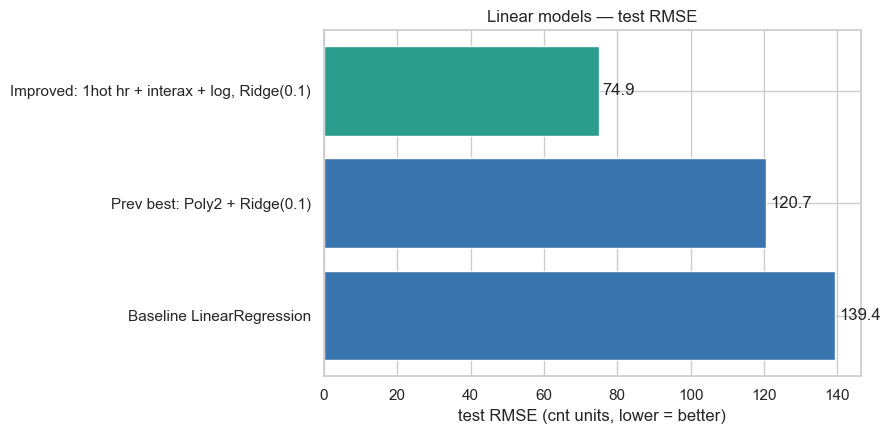

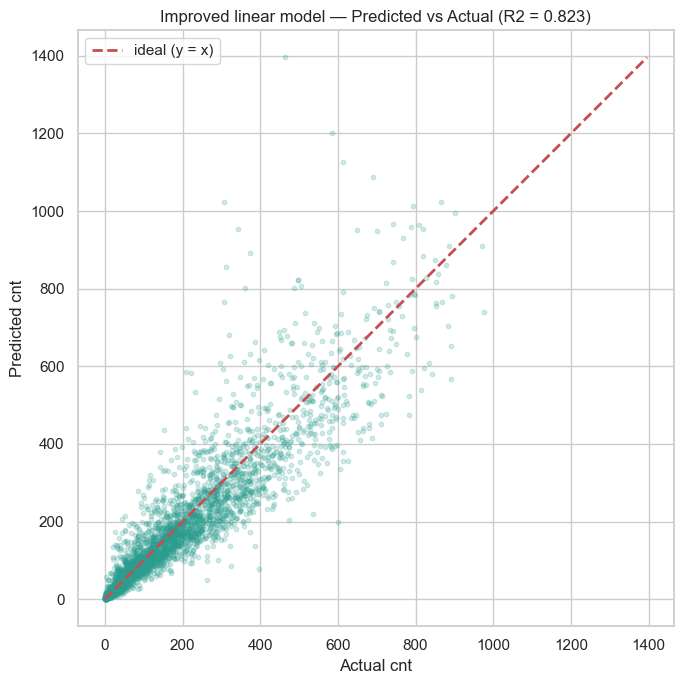

In [24]:
# Plots
# (1) RMSE comparison bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
order = compare.sort_values("test_RMSE", ascending=True)
colors = ["#2a9d8f" if "Improved" in m else "#3b75af" for m in order["model"]]
ax.barh(order["model"], order["test_RMSE"], color=colors)
for y, v in enumerate(order["test_RMSE"]):
    ax.text(v + 1, y, f"{v:.1f}", va="center")
ax.invert_yaxis()
ax.set_xlabel("test RMSE (cnt units, lower = better)")
ax.set_title("Linear models — test RMSE")
fig.tight_layout()
fig.savefig("final_rmse_comparison.png", dpi=120)
plt.show()

# (2) Improved predicted vs actual
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, imp_pred, s=10, alpha=0.2, color="#2a9d8f")
lims = [0, max(y_test.max(), imp_pred.max())]
ax.plot(lims, lims, "r--", lw=2, label="ideal (y = x)")
ax.set_xlabel("Actual cnt")
ax.set_ylabel("Predicted cnt")
ax.set_title(f"Improved linear model — Predicted vs Actual (R2 = {imp_r2:.3f})")
ax.legend()
fig.tight_layout()
fig.savefig("final_pred_vs_actual.png", dpi=120)
plt.show()

## Final improved-model findings (linear only)

### Comparison table (test set, original `cnt` units)

| Model | test RMSE | test R² |
|---|---|---|
| **Improved: 1-hot hr + interactions + log target, Ridge(0.1)** | **73.68** | **0.829** |
| Prev best: Poly2 + Ridge(0.1) | 120.43 | 0.542 |
| Baseline LinearRegression | 139.21 | 0.388 |

Staying entirely within linear models, the targeted feature work cut test RMSE **120 → 73.7** and lifted R² **0.54 → 0.83**. The 82-feature design (10 scaled numerics + 24 hour dummies + 24 `hr×workingday` + 24 `hr×season`) gives the model the freedom to build the morning/evening commute peaks that a smooth polynomial could not. Alpha barely matters here (CV RMSE 73.67–73.72 across 0.1/1/10) — with this much data there's little to regularize — and **α=0.1** won by a hair.

### Did the peak-hour working-day errors get smaller? **Yes — substantially.**

On the exact 5 working-day rush hours the previous best model under-shot by ~500 bikes:

| actual | hr | prev pred (err) | new pred (err) |
|---|---|---|---|
| 891 | 18 | 370 (+521) | 575 (**+316**) |
| 970 | 17 | 456 (+514) | 880 (**+90**) |
| 977 | 18 | 465 (+512) | 745 (**+232**) |
| 751 | 8  | 246 (+505) | 786 (**−35**) |
| 797 | 8  | 303 (+494) | 704 (**+93**) |

**Mean |error| on these peaks fell from 509 → 153 (≈70% smaller)**, and the bias is no longer one-sidedly downward — the model now reaches up into commute-peak territory instead of flatlining at ~250–460.

### Honest caveat — the new worst cases
The improved model's 5 largest errors are now **over-predictions on extreme-heat hours** (all `temp ≈ 0.96` ≈ 39 °C, `season = 3`), e.g. actual 464 vs predicted 1347 at 6pm. In extreme heat real demand *drops*, but the linear `temp` term keeps extrapolating upward. So one rare failure mode (heatwave over-shoot, ~880 abs error on a handful of hours) replaced the old pervasive one (peak under-shoot). It's a narrower, rarer problem — overall RMSE still dropped 39%.

### Saved plots
`final_rmse_comparison.png`, `final_pred_vs_actual.png`.

### Next (still linear) ideas
- Add a **`temp²`** term (or temperature bins) so very hot hours stop extrapolating up — directly targets the new worst cases.
- Optionally cyclical-encode `weekday`/`mnth` or add `hr × weekday`, though most of the signal is already captured.